<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Benchmark 1 — Perturbative versus Numerical Propagation
---
This notebook compares execution time and speedup of the perturbative (`analytical`) and segmented matrix-exponential (`numerical`) methods over the same four physical pipelines used by the intrinsic-validation notebook.

---

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Pure-Flavour-States-through-Earth) | **Pure Flavour States through Earth** |
| [4](#4.-Solar-Neutrinos-to-the-Detector) | **Solar Neutrinos to the Detector** |
| [5](#5.-Atmospheric-Neutrinos-to-the-Surface) | **Atmospheric Neutrinos to the Surface** |
| [6](#6.-Atmospheric-Neutrinos-to-the-Detector) | **Atmospheric Neutrinos to the Detector** |
| [7](#7.-Resource-Consumption) | **Resource Consumption** |
| [8](#8.-Summary) | **Summary** |


## 0. Theoretical Framework

This stage defines and evaluates theoretical framework under the physical, numerical, and hardware conditions stated above, with explicit control of accuracy and reproducibility.


### 0.1 Compared algorithms

The perturbative method evaluates exact constant-density evolution and a first-order residual-density correction inside each fitted material segment. The numerical method samples the trajectory and composes $S_j=\exp(-iH_j\Delta x_j)$ over many short intervals. Both implement the same Schrödinger equation in matter [1] but have different computational costs.


### 0.2 Timing and speedup

For each pair of energy- and angular-grid sizes, elapsed wall time is measured after one warm-up execution. GPU work is asynchronous, so CUDA is synchronized immediately before and after every timed call. The reported estimator is the median of repeated executions,

$$t_m=\mathrm{median}(t_{m,1},\ldots,t_{m,N}),\qquad \mathcal{S}=\frac{t_{\rm numerical}}{t_{\rm perturbative}}.$$

Thus $\mathcal{S}>1$ means that perturbative propagation is faster. Timing includes construction of the medium trajectory/profile and probability projection, but excludes plotting and comparison-table construction.


### 0.3 Fair-comparison conditions

Both branches receive identical energy and angular grids, chunk boundaries, oscillation parameters, density sources and detector geometry. The benchmark scans every combination $N_E,N_\theta\in\{4,8,16,32,64,128\}$, giving one timing comparison per grid-size pair. Earth reunitarization is enabled for the perturbative branch. The numerical discretizations use 400 Earth steps and 600 atmosphere steps. Chunking changes peak memory and dispatch overhead but not the mathematical grid evaluated by either method.

**References**

- [1] L. Wolfenstein, *Neutrino oscillations in matter*, Phys. Rev. D **17**, 2369 (1978).
- [2] S. P. Mikheyev and A. Yu. Smirnov, *Resonant amplification of neutrino oscillations in matter*, Sov. J. Nucl. Phys. **42**, 913 (1985).
- [3] CUDA Programming Guide, *Asynchronous concurrent execution* — device synchronization requirements for host-side timing.


## 1. Libraries

This stage defines and evaluates libraries under the physical, numerical, and hardware conditions stated above, with explicit control of accuracy and reproducibility.


In [1]:
from __future__ import annotations

%matplotlib inline
import os

# These limits must be defined before importing NumPy or PyTorch. Restart the
# kernel after changing them so that every native backend observes them.
CPU_THREADS = 8
TORCH_INTEROP_THREADS = 1
CUDA_DEVICE = '0'  # Set to '' to force CPU execution.
for variable in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ[variable] = str(CPU_THREADS)
os.environ['CUDA_VISIBLE_DEVICES'] = CUDA_DEVICE

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import torch

torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(TORCH_INTEROP_THREADS)
except RuntimeError:
    # PyTorch only permits changing this setting before inter-op work starts.
    if torch.get_num_interop_threads() != TORCH_INTEROP_THREADS: raise

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show
from tpeanuts.notebooks.benchmark.benchmark_helpers import iter_grid_chunks, plot_grid_resource_scaling, reduce_tensor_chunks, timed_resources
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state
from tpeanuts.medium.solar.profile import SolarMediumProfile
from tpeanuts.source.solar import SolarNeutrinoSource
from tpeanuts.medium.solar.probability import solar_probability_mass
from tpeanuts.medium.atmosphere.profile import AtmosphereParameters
from tpeanuts.medium.atmosphere.evolutor import atmosphere_evolutor
from tpeanuts.medium.atmosphere.probability import atmosphere_probability_transition
from tpeanuts.util.context import RuntimeContext

## 2. Paths and Configuration

This stage defines and evaluates paths and configuration under the physical, numerical, and hardware conditions stated above, with explicit control of accuracy and reproducibility.


### 2.1 Paths

`load_notebook_config()` resolves the project and applies the shared plotting/runtime style. All figures and CSV tables are saved under the notebook-relative output path `benchmark/`.

**Expected results:**<br>
package and output directories exist and the selected runtime device is reported.


In [2]:
config = load_notebook_config()
DEVICE, DTYPE = config.device, config.dtype
context = RuntimeContext.resolve(DEVICE, DTYPE)
OUTPUT_DIR = config.output_dir('benchmark')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Package dir : {config.package_dir}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Device      : {context.device}   dtype: {context.dtype}')
print(f'CPU threads : {torch.get_num_threads()} intra-op / {torch.get_num_interop_threads()} inter-op')

Package dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Output dir  : v:\output\benchmark
Device      : cuda:0   dtype: torch.float64
CPU threads : 8 intra-op / 1 inter-op


### 2.2 Configuration

The benchmark scans all Cartesian combinations of the energy- and angular-grid sizes shown below. This intentionally produces expensive large-grid workloads; the notebook is supplied unexecuted so the user can select the desired device and repetition count before running it.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | `_SM_NUFIT52_NO` | Three-flavour normal ordering |
| Energy-grid sizes | 4, 8, 16, 32, 64, 128 | Scaling axis $N_E$ |
| Angular-grid sizes | 4, 8, 16, 32, 64, 128 | Scaling axis $N_\theta$ |
| Warm-up executions | 1 | Per method and scenario |
| Timed repetitions | 3 | Median reported |
| Earth numerical steps | 400 | Constant-density intervals |
| Atmosphere numerical steps | 600 | Constant-density intervals |
| Atmosphere perturbative fit | 6 cubic segments | Automatically fitted |
| Detector depth | 1000 m | Shared geometry |
| CPU threads | 8 intra-op, 1 inter-op | PyTorch, OpenMP and BLAS limit |
| Process RAM budget | 16 GiB | Checked before and after every chunk |
| PyTorch VRAM fraction | 70% | Per-process CUDA allocator limit |
| Energy/angle chunks | 16 / 8 | Common to both propagation methods |
| Resource sampling | 20 ms | Process RSS and CPU utilization |

**Expected results:**<br>
both methods build finite probability tensors with identical shapes; timing varies with hardware but the speedup definition remains unchanged.


In [3]:
N_EGRIDS = 5
N_AGRIDS = 5
ENERGY_GRID_SIZES = [4*2**n for n in range(N_EGRIDS)]
ANGLE_GRID_SIZES = [4*2**n for n in range(N_AGRIDS)]
WARMUP, REPEATS = 1, 3
MAX_RAM_GB, MAX_VRAM_FRACTION = 16.0, 0.70
ENERGY_CHUNK_SIZE, ANGLE_CHUNK_SIZE = 16, 8
RESOURCE_SAMPLE_INTERVAL_S = 0.02
EMPTY_CUDA_CACHE_BETWEEN_CASES = True
DEPTH_M, N_EARTH_STEPS = 1000.0, 400
CDTYPE = torch.complex128 if DTYPE == torch.float64 else torch.complex64
oscillation = PropagationConfig.oscillation_parameters_from_preset('_SM_NUFIT52_NO', context=context, antinu=False)
earth = EarthProfile(params=EarthParameters(profile_perturbative_kwargs={'density_file': str(config.earth_density_file), 'tabulated_density': False}), context=context)
solar_medium = SolarMediumProfile.default(context=context)
solar_source = SolarNeutrinoSource.default(context=context)
atmosphere = AtmosphereParameters(atmosphere_density_source='exponential', nsteps=600, matter=True, perturbative_segments=6, perturbative_degree=3)
print(DEVICE,CDTYPE, DTYPE)
BASIS = torch.eye(3, device=DEVICE, dtype=CDTYPE)
benchmark_tables = []
if context.device.type == 'cuda':
    torch.cuda.set_per_process_memory_fraction(MAX_VRAM_FRACTION, device=context.device)
print(f'RAM budget  : {MAX_RAM_GB:.1f} GiB process RSS')
print(f'Chunks      : energy={ENERGY_CHUNK_SIZE}, angle={ANGLE_CHUNK_SIZE}')
if context.device.type == 'cuda': print(f'VRAM limit  : {MAX_VRAM_FRACTION:.0%} of {torch.cuda.get_device_name(context.device)}')

cuda:0 torch.complex128 torch.float64
RAM budget  : 16.0 GiB process RSS
Chunks      : energy=16, angle=8
VRAM limit  : 70% of NVIDIA GeForce GTX 1080 Ti


### 2.3 Local Helpers

The helper synchronizes CUDA, warms both paths, processes both methods with identical energy-angle chunks, and reduces each result to a finite checksum to force materialization without retaining the complete grid. A background sampler records process RAM and CPU consumption, while CUDA peak statistics provide allocated and reserved VRAM. Each section reports timing, speedup and resource peaks.

**Expected results:**<br>
- Each scenario produces 36 rows with positive timings, finite speedups and resource measurements below the configured budgets.
- Smaller chunks reduce peak memory at the cost of additional dispatch overhead.


In [4]:
def grid_chunks(energy, angles):
    return iter_grid_chunks(energy, angles, energy_chunk_size=ENERGY_CHUNK_SIZE, angle_chunk_size=ANGLE_CHUNK_SIZE, max_ram_gb=MAX_RAM_GB)

def reduce_chunks(chunks):
    return reduce_tensor_chunks(chunks, device=DEVICE, dtype=DTYPE, max_ram_gb=MAX_RAM_GB)

def timed(fn, method):
    return timed_resources(lambda: fn(method), device=DEVICE, repeats=REPEATS, warmups=WARMUP, max_ram_gb=MAX_RAM_GB, sample_interval_s=RESOURCE_SAMPLE_INTERVAL_S, empty_cuda_cache=EMPTY_CUDA_CACHE_BETWEEN_CASES, cpu_normalization_cores=CPU_THREADS)

def benchmark_grid(name, workload_factory, filename):
    records = []
    for n_energy in ENERGY_GRID_SIZES:
        print('Energy Grid Size:',n_energy)
        for n_angle in ANGLE_GRID_SIZES:
            print('.',end='')
            fn = workload_factory(n_energy, n_angle)
            samples_a, resources_a = timed(fn, 'analytical')
            samples_n, resources_n = timed(fn, 'numerical')
            t_a, t_n = np.median(samples_a), np.median(samples_n)
            records.append({'case': name, 'n_energy': n_energy, 'n_angle': n_angle, 'perturbative_s': t_a, 'numerical_s': t_n, 'speedup': t_n/t_a, 'perturbative_std_s': samples_a.std(), 'numerical_std_s': samples_n.std(), **{f'perturbative_{key}': value for key, value in resources_a.items()}, **{f'numerical_{key}': value for key, value in resources_n.items()}})
        print()
    frame = pd.DataFrame(records); benchmark_tables.append(frame); display(frame)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for ax, column, title in zip(axes, ('perturbative_s', 'numerical_s', 'speedup'), ('Perturbative time [s]', 'Numerical time [s]', 'Speedup numerical / perturbative')):
        pivot = frame.pivot(index='n_angle', columns='n_energy', values=column)
        values = pivot.to_numpy(); norm = mcolors.LogNorm(vmin=values.min(), vmax=values.max()) if values.max() > values.min() else None
        image = ax.imshow(values, origin='lower', aspect='auto', cmap='viridis' if column != 'speedup' else 'RdYlGn', norm=norm)
        ax.set_xticks(range(len(pivot.columns)), pivot.columns); ax.set_yticks(range(len(pivot.index)), pivot.index)
        ax.set(xlabel='Energy-grid size', ylabel='Angular-grid size', title=title); fig.colorbar(image, ax=ax)
        if column == 'speedup':
            for row in range(values.shape[0]):
                for col in range(values.shape[1]): ax.text(col, row, f'{values[row,col]:.1f}x', ha='center', va='center', fontsize=7)
    fig.suptitle(name); fig.tight_layout(); save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)
    resource_filename = filename.replace('_scaling.png', '_resource_scaling.png')
    plot_grid_resource_scaling(frame, title=name, filename=resource_filename, output_dir=OUTPUT_DIR, show_plots=config.show_plots)
    return frame

def atmosphere_detector_workload_factory(n_energy, n_angle):
    energy = torch.logspace(2.0, 4.5, n_energy, device=DEVICE, dtype=DTYPE)
    zenith = torch.linspace(30.0, 180.0, n_angle, device=DEVICE, dtype=DTYPE)
    def workload(method):
        def chunks():
            for energy_chunk, zenith_chunk in grid_chunks(energy, zenith):
                S_atm, _ = atmosphere_evolutor(oscillation, energy_chunk[:, None], 25.0, zenith_chunk[None, :], DEPTH_M/1000.0, atmosphere=atmosphere, context=context, method=method)
                eta_chunk = torch.pi - torch.deg2rad(zenith_chunk)
                for state in BASIS:
                    if method == 'analytical':
                        surface_state = torch.matmul(S_atm, state)
                        yield earth_probability_state(surface_state, earth, oscillation, energy_chunk[:, None], eta_chunk[None, :], DEPTH_M, method=method, massbasis=False, reunitarize=True)
                    else:
                        for i_angle, eta in enumerate(eta_chunk):
                            surface_state = torch.matmul(S_atm[:, i_angle], state)
                            yield earth_probability_state(surface_state, earth, oscillation, energy_chunk[:, None], eta, DEPTH_M, method=method, massbasis=False, nsteps=N_EARTH_STEPS, context=context)
                del S_atm
        return reduce_chunks(chunks())
    return workload

def atmosphere_surface_workload_factory(n_energy, n_angle):
    energy = torch.logspace(2.0, 5.0, n_energy, device=DEVICE, dtype=DTYPE)
    angles = torch.linspace(0.0, 180.0, n_angle, device=DEVICE, dtype=DTYPE)
    def workload(method):
        return reduce_chunks(atmosphere_probability_transition(oscillation, e[:, None], 25.0, a[None, :], DEPTH_M/1000.0, atmosphere=atmosphere, context=context, method=method) for e, a in grid_chunks(energy, angles))
    return workload

def solar_workload_factory(n_energy, n_angle):
    energy = torch.linspace(0.5, 15.0, n_energy, device=DEVICE, dtype=DTYPE)
    angles = torch.linspace(0.10, 1.45, n_angle, device=DEVICE, dtype=DTYPE)
    weights = solar_probability_mass(oscillation, energy, solar_medium, solar_source, '8B')
    def workload(method):
        def chunks():
            for energy_chunk, angle_chunk in grid_chunks(energy, angles):
                e0 = int(torch.searchsorted(energy, energy_chunk[0]).item())
                weight_chunk = weights[e0:e0 + energy_chunk.numel()]
                if method == 'analytical':
                    yield earth_probability_state(weight_chunk, earth, oscillation, energy_chunk[:, None], angle_chunk[None, :], DEPTH_M, method=method, massbasis=True, reunitarize=True)
                else:
                    for eta in angle_chunk:
                        yield earth_probability_state(weight_chunk, earth, oscillation, energy_chunk[:, None], eta, DEPTH_M, method=method, massbasis=True, nsteps=N_EARTH_STEPS, context=context)
        return reduce_chunks(chunks())
    return workload

def earth_workload_factory(n_energy, n_angle):
    energy = torch.logspace(np.log10(100.0), np.log10(2.0e4), n_energy, device=DEVICE, dtype=DTYPE)
    angles = torch.linspace(0.05, 1.50, n_angle, device=DEVICE, dtype=DTYPE)
    def workload(method):
        def chunks():
            for energy_chunk, angle_chunk in grid_chunks(energy, angles):
                for state in BASIS:
                    if method == 'analytical':
                        yield earth_probability_state(state, earth, oscillation, energy_chunk[:, None], angle_chunk[None, :], DEPTH_M, method=method, massbasis=False, reunitarize=True)
                    else:
                        for eta in angle_chunk:
                            yield earth_probability_state(state, earth, oscillation, energy_chunk[:, None], eta, DEPTH_M, method=method, massbasis=False, nsteps=N_EARTH_STEPS, context=context)
        return reduce_chunks(chunks())
    return workload


## 3. Pure Flavour States through Earth

The workload propagates all three pure flavour states over a common energy–nadir grid. The analytical path evaluates every energy-angle chunk as one broadcast tensor, whereas the numerical path retains its required scalar-trajectory angular loop.

**Expected results:**<br>
- Perturbative propagation should avoid hundreds of local matrix exponentials per trajectory and therefore achieve a speedup, particularly on CPU.
- The accompanying 2×4 resource grid shows peak RAM, allocated VRAM, normalized CPU and GPU utilization versus energy-grid size (top) and angular-grid size (bottom).


Energy Grid Size: 4
.....
Energy Grid Size: 8
.....
Energy Grid Size: 16
.....
Energy Grid Size: 32
.....
Energy Grid Size: 64
.....


,case,n_energy,n_angle,perturbative_s,numerical_s,speedup,perturbative_std_s,numerical_std_s,perturbative_ram_gb,perturbative_cpu_percent,perturbative_gpu_percent,perturbative_vram_allocated_gb,perturbative_vram_reserved_gb,numerical_ram_gb,numerical_cpu_percent,numerical_gpu_percent,numerical_vram_allocated_gb,numerical_vram_reserved_gb
0,Pure flavour through Earth,4,4,0.112391,0.176209,1.567823,0.002483,0.013423,1.007568,12.6000,11.0,0.009566,0.021484,1.052277,12.6000,28.0,0.011060,0.021484
1,Pure flavour through Earth,4,8,0.118988,0.378240,3.178792,0.001547,0.005270,1.052586,12.6000,21.0,0.010915,0.021484,1.052631,12.6000,41.0,0.011060,0.021484
2,Pure flavour through Earth,4,16,0.235023,0.684120,2.910861,0.003006,0.020249,1.052811,13.0250,23.0,0.010915,0.021484,1.052990,12.6000,37.0,0.011060,0.021484
3,Pure flavour through Earth,4,32,0.452157,1.386677,3.066806,0.009306,0.030195,1.053017,12.6000,24.0,0.010915,0.021484,1.053051,13.0250,36.0,0.011060,0.021484
4,Pure flavour through Earth,4,64,0.921286,2.974724,3.228882,0.081798,0.031010,1.053070,13.0250,40.0,0.010915,0.021484,1.053524,12.6000,35.0,0.011060,0.021484
5,Pure flavour through Earth,8,4,0.121388,0.203868,1.679472,0.006456,0.006223,1.053680,13.0250,24.0,0.010915,0.021484,1.053841,12.6000,42.0,0.013945,0.023438
6,Pure flavour through Earth,8,8,0.142593,0.410414,2.878224,0.007043,0.003919,1.053959,12.6000,18.0,0.013613,0.021484,1.054024,12.6000,43.0,0.013945,0.023438
7,Pure flavour through Earth,8,16,0.253426,0.835828,3.298117,0.007685,0.018673,1.054028,13.0250,24.0,0.013613,0.021484,1.054031,12.6000,45.0,0.013945,0.023438
8,Pure flavour through Earth,8,32,0.494774,1.660290,3.355655,0.002874,0.026041,1.054092,13.0250,26.0,0.013613,0.021484,1.054104,13.0250,44.0,0.013945,0.023438
9,Pure flavour through Earth,8,64,0.943469,3.290241,3.487385,0.017834,0.016827,1.054081,13.0250,25.0,0.013613,0.021484,1.054161,13.0250,44.0,0.013945,0.023438


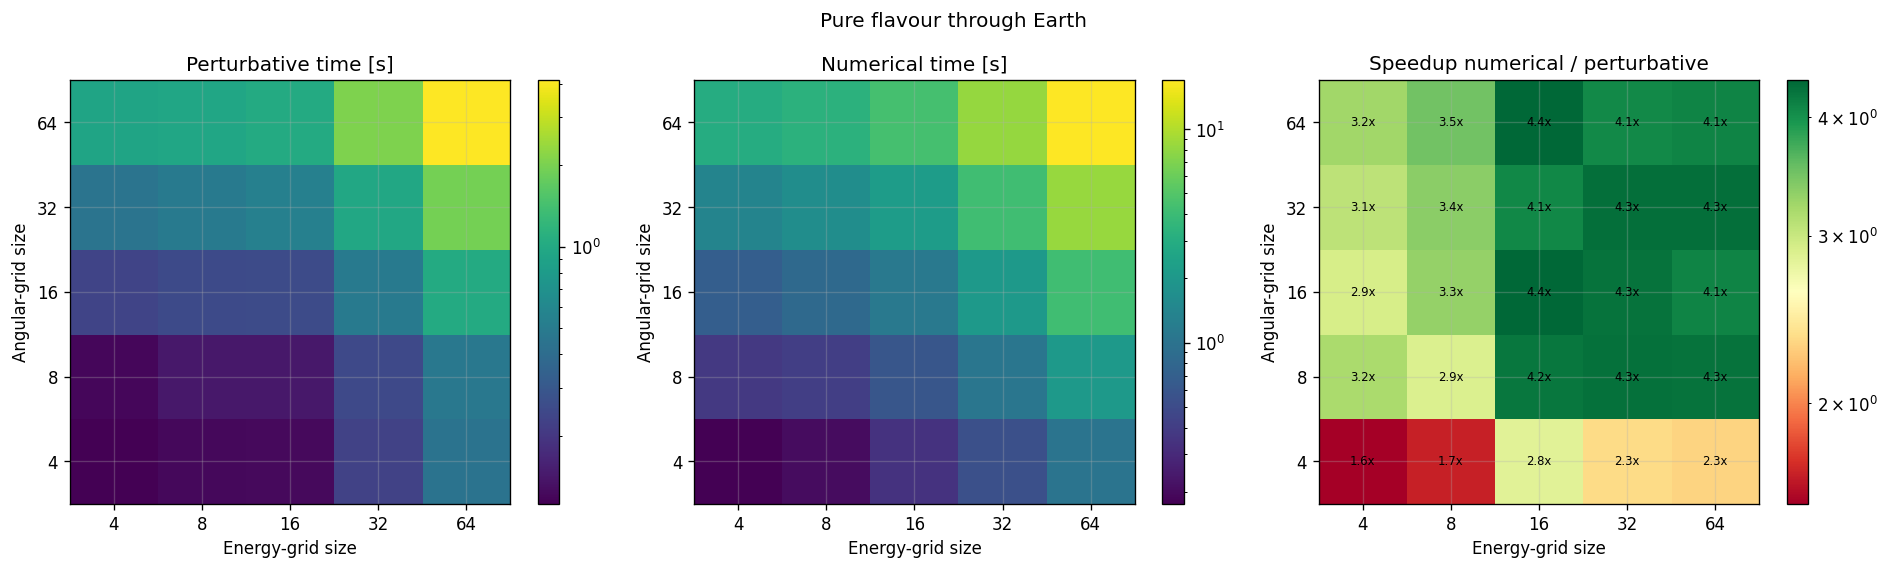

v:\output\benchmark\benchmark1_fig1_earth_scaling.png


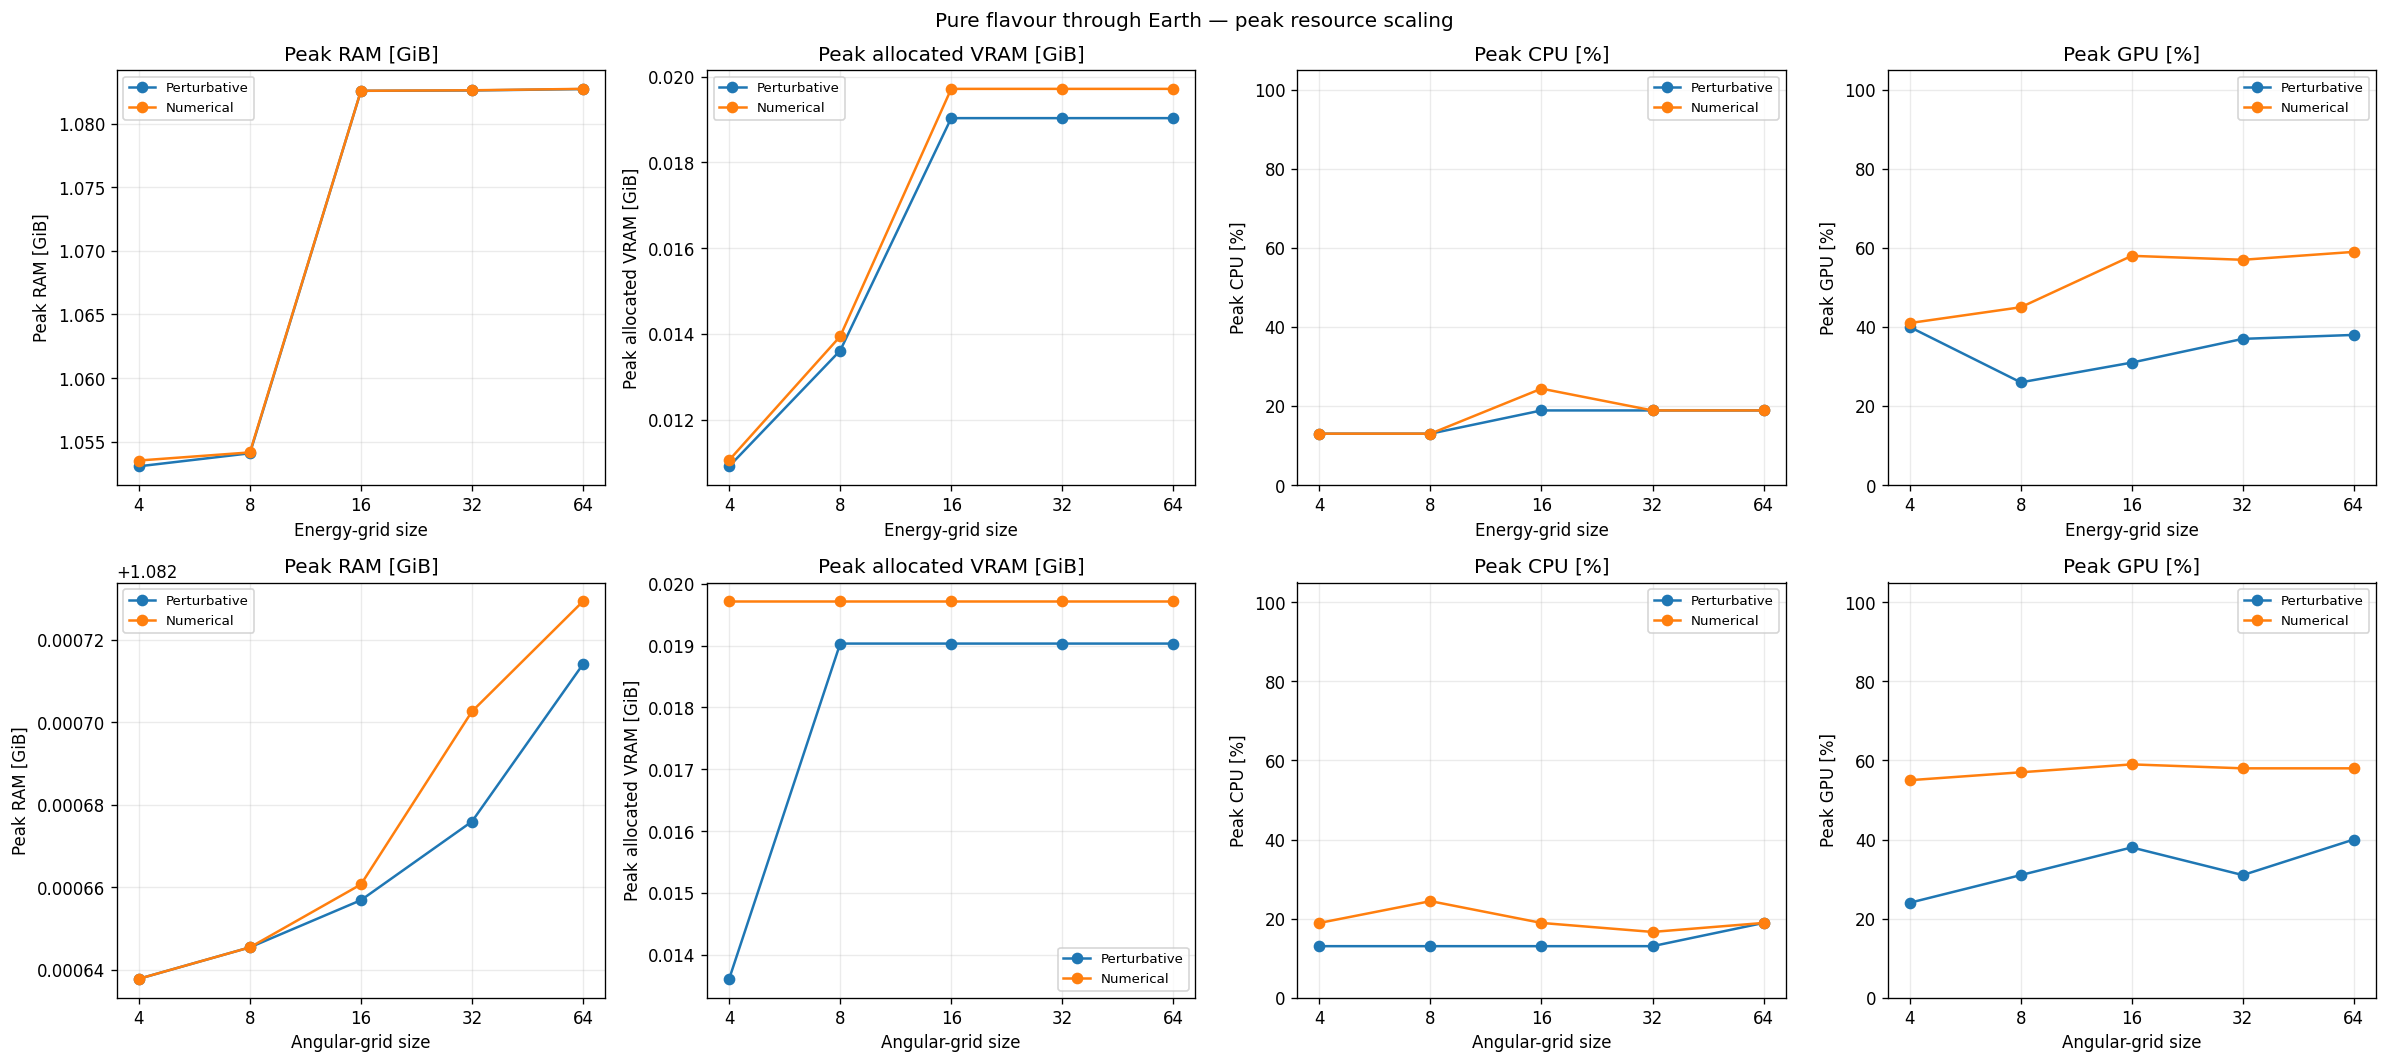

v:\output\benchmark\benchmark1_fig1_earth_resource_scaling.png


In [5]:

earth_df = benchmark_grid('Pure flavour through Earth', earth_workload_factory, 'benchmark1_fig1_earth_scaling.png')


## 4. Solar Neutrinos to the Detector

Solar $^8$B mass weights are precomputed outside the timed region; the benchmark measures only their Earth propagation to the detector. The analytical path broadcasts each complete energy–nadir chunk, while the numerical path loops over scalar trajectories.

**Expected results:**<br>
- The relative advantage follows the Earth workload, while the absolute time is lower because only one incoherent state is propagated instead of three pure states.
- The accompanying 2×4 resource grid shows peak RAM, allocated VRAM, normalized CPU and GPU utilization versus energy-grid size (top) and angular-grid size (bottom).


Energy Grid Size: 4
.....
Energy Grid Size: 8
.....
Energy Grid Size: 16
.....
Energy Grid Size: 32
.....
Energy Grid Size: 64
.....


,case,n_energy,n_angle,perturbative_s,numerical_s,speedup,perturbative_std_s,numerical_std_s,perturbative_ram_gb,perturbative_cpu_percent,perturbative_gpu_percent,perturbative_vram_allocated_gb,perturbative_vram_reserved_gb,numerical_ram_gb,numerical_cpu_percent,numerical_gpu_percent,numerical_vram_allocated_gb,numerical_vram_reserved_gb
0,Solar production to detector,4,4,0.048194,0.097535,2.023812,0.000552,0.001011,1.116291,12.6000,13.0,0.009567,0.021484,1.112343,12.600,46.0,0.011060,0.023438
1,Solar production to detector,4,8,0.048547,0.181664,3.742023,0.000920,0.010466,1.112350,13.0250,36.0,0.010915,0.021484,1.112362,12.600,48.0,0.011060,0.023438
2,Solar production to detector,4,16,0.088838,0.258147,2.905824,0.000504,0.002497,1.112370,12.6000,34.0,0.010915,0.021484,1.112370,12.600,53.0,0.011060,0.023438
3,Solar production to detector,4,32,0.155520,0.502338,3.230046,0.000641,0.012623,1.112373,12.6000,15.0,0.010915,0.021484,1.112373,13.025,41.0,0.011060,0.023438
4,Solar production to detector,4,64,0.309695,0.988421,3.191591,0.011519,0.000889,1.112442,12.6000,16.0,0.010915,0.021484,1.112442,13.025,40.0,0.011060,0.023438
5,Solar production to detector,8,4,0.036898,0.074865,2.028966,0.001545,0.000806,1.112442,13.0250,16.0,0.010915,0.021484,1.112446,12.600,25.0,0.013945,0.025391
6,Solar production to detector,8,8,0.043218,0.150394,3.479859,0.002286,0.005400,1.112446,12.6000,27.0,0.013613,0.021484,1.112446,12.600,47.0,0.013945,0.025391
7,Solar production to detector,8,16,0.079000,0.304502,3.854467,0.000616,0.004365,1.112446,12.6000,11.0,0.013613,0.021484,1.112446,12.600,51.0,0.013945,0.025391
8,Solar production to detector,8,32,0.156845,0.612065,3.902344,0.001406,0.004029,1.112446,12.6000,18.0,0.013613,0.021484,1.112446,13.025,54.0,0.013945,0.025391
9,Solar production to detector,8,64,0.307574,1.221083,3.970040,0.013676,0.003479,1.112446,12.6000,19.0,0.013613,0.021484,1.112446,12.600,55.0,0.013945,0.025391


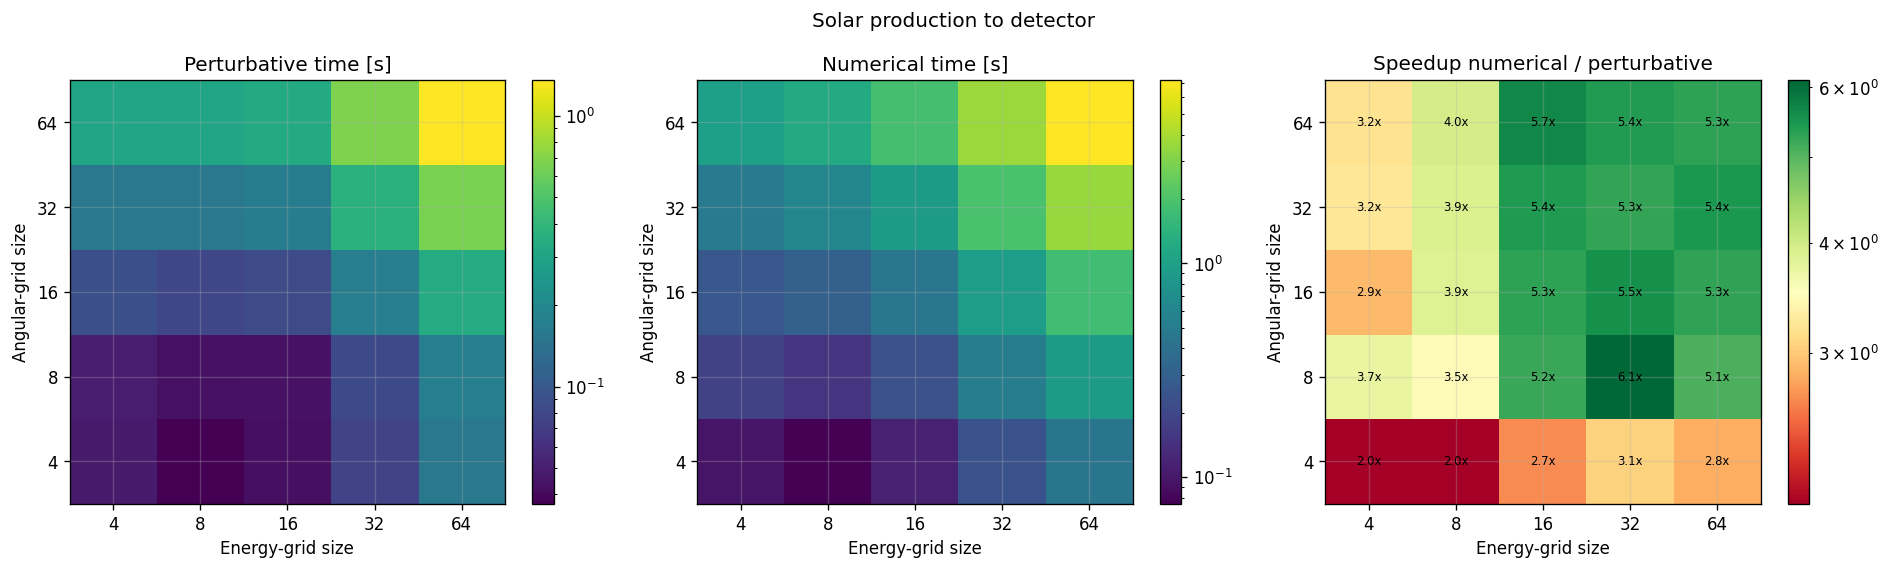

v:\output\benchmark\benchmark1_fig2_solar_detector_scaling.png


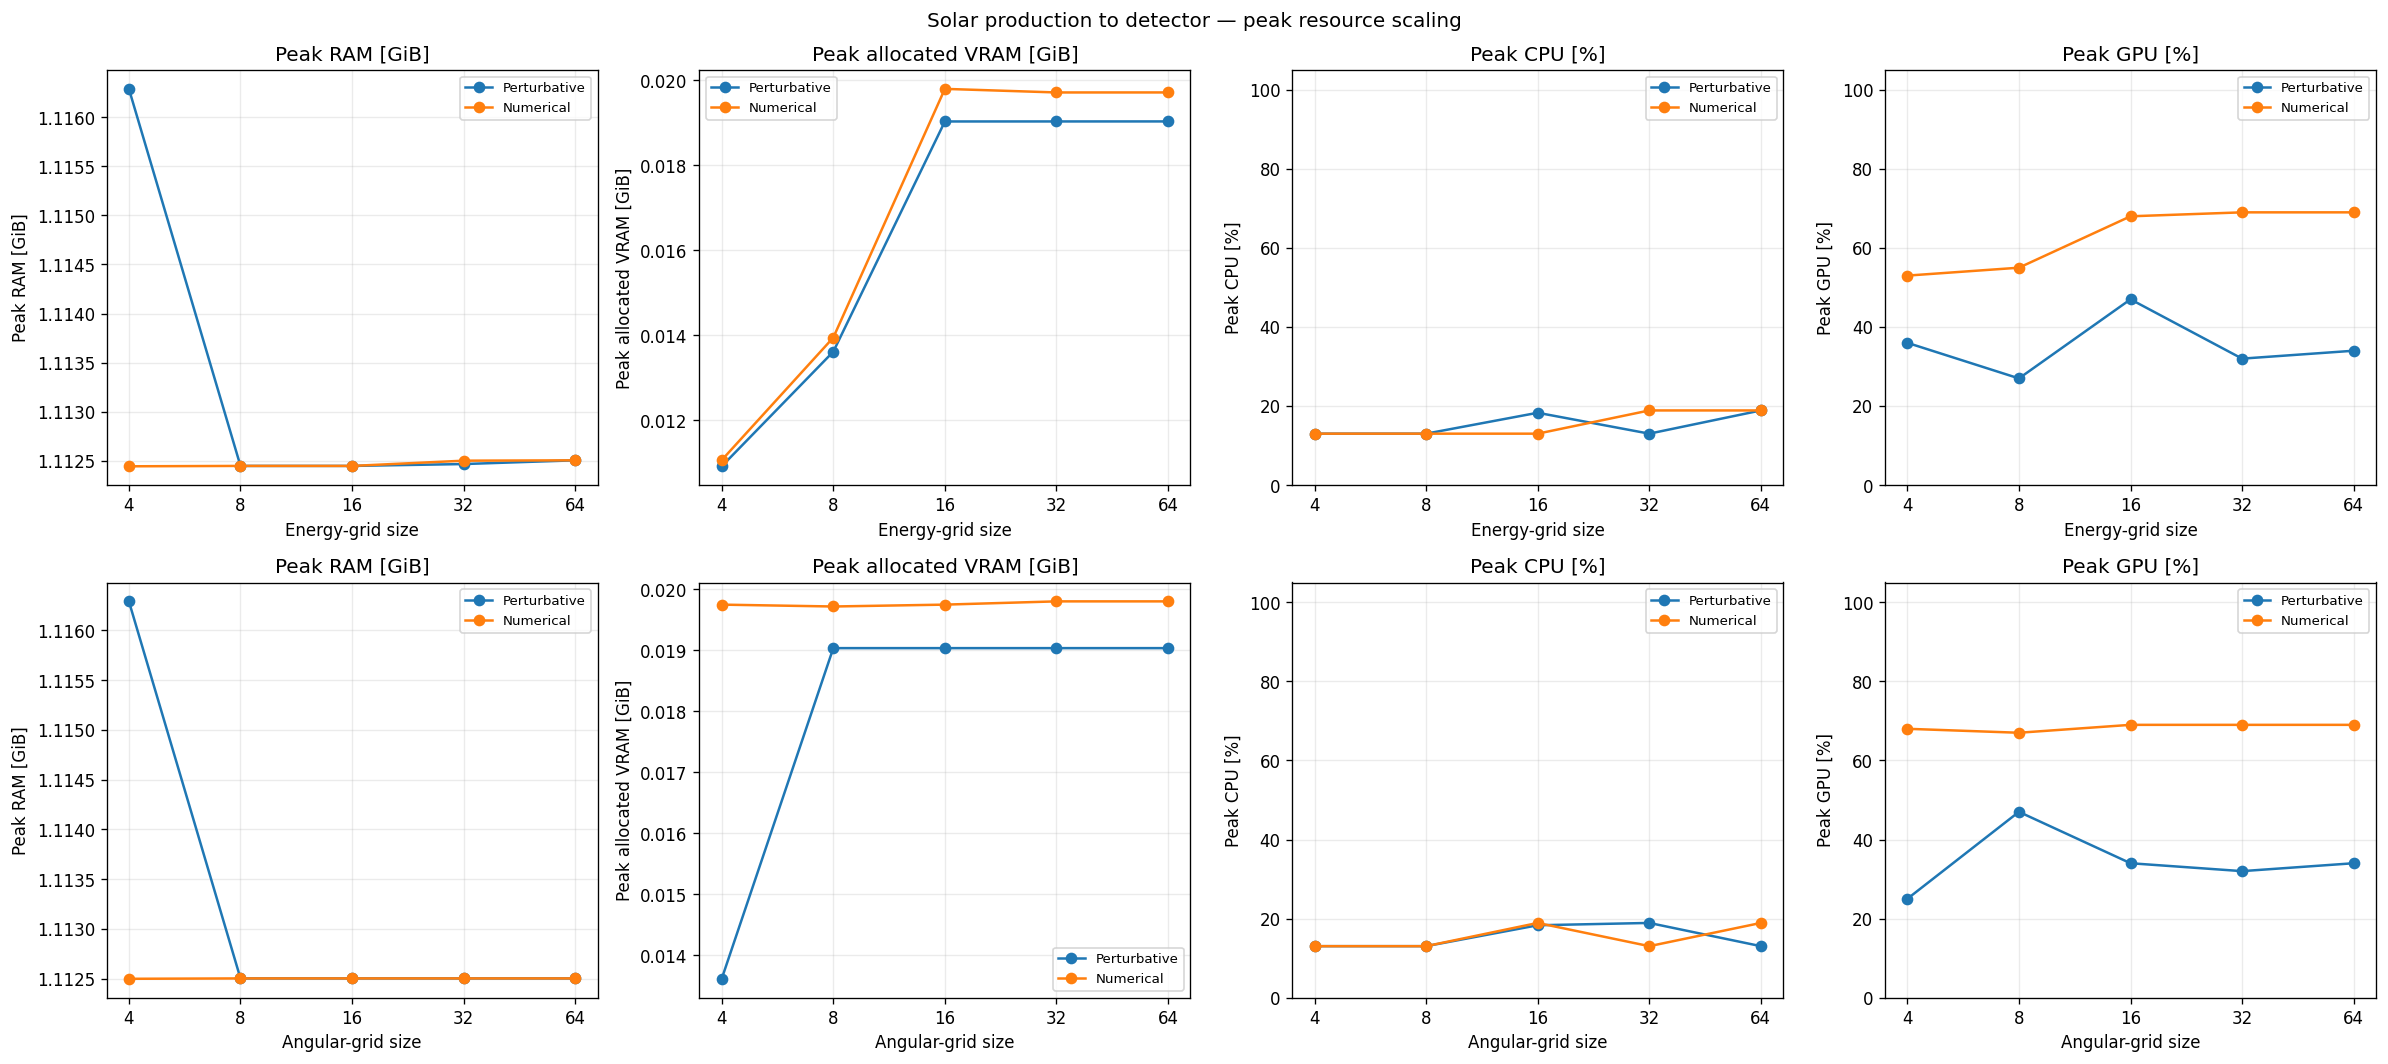

v:\output\benchmark\benchmark1_fig2_solar_detector_resource_scaling.png


In [6]:

solar_df = benchmark_grid('Solar production to detector', solar_workload_factory, 'benchmark1_fig2_solar_detector_scaling.png')


## 5. Atmospheric Neutrinos to the Surface

The complete atmosphere transition matrix is computed in one batched call over energy and zenith angle. Profile construction and automatic polynomial fitting are included in the perturbative timing.

**Expected results:**<br>
- Six fitted perturbative segments should require substantially fewer matrix operations than 600 numerical segments, producing the largest speedup of the notebook.
- The accompanying 2×4 resource grid shows peak RAM, allocated VRAM, normalized CPU and GPU utilization versus energy-grid size (top) and angular-grid size (bottom).


Energy Grid Size: 4
.....
Energy Grid Size: 8
.....
Energy Grid Size: 16
.....
Energy Grid Size: 32
.....
Energy Grid Size: 64
.....


,case,n_energy,n_angle,perturbative_s,numerical_s,speedup,perturbative_std_s,numerical_std_s,perturbative_ram_gb,perturbative_cpu_percent,perturbative_gpu_percent,perturbative_vram_allocated_gb,perturbative_vram_reserved_gb,numerical_ram_gb,numerical_cpu_percent,numerical_gpu_percent,numerical_vram_allocated_gb,numerical_vram_reserved_gb
0,Atmosphere production to surface,4,4,0.013658,0.025002,1.830635,0.000261,0.000170,1.162624,0.0000,0.0,0.009750,0.021484,1.158615,0.000,0.0,0.025216,0.041016
1,Atmosphere production to surface,4,8,0.014589,0.039573,2.712565,0.000556,0.000814,1.158615,0.0000,0.0,0.011301,0.021484,1.158615,12.600,30.0,0.043850,0.050781
2,Atmosphere production to surface,4,16,0.026700,0.082128,3.075955,0.001671,0.001600,1.158627,12.2125,21.0,0.011301,0.021484,1.158627,13.025,43.0,0.043850,0.050781
3,Atmosphere production to surface,4,32,0.051960,0.152719,2.939153,0.001807,0.000888,1.158627,12.6000,13.0,0.011301,0.021484,1.158627,12.600,66.0,0.043850,0.050781
4,Atmosphere production to surface,4,64,0.104937,0.300421,2.862865,0.004558,0.002849,1.158630,13.0250,55.0,0.011301,0.021484,1.158642,13.025,81.0,0.043850,0.050781
5,Atmosphere production to surface,8,4,0.013563,0.039248,2.893762,0.000254,0.000073,1.158638,0.0000,0.0,0.011295,0.021484,1.158642,13.025,33.0,0.043762,0.050781
6,Atmosphere production to surface,8,8,0.013927,0.070045,5.029490,0.000037,0.000075,1.158642,0.0000,0.0,0.014390,0.021484,1.158642,12.600,35.0,0.076159,0.099609
7,Atmosphere production to surface,8,16,0.028212,0.135322,4.796714,0.001168,0.000382,1.158642,12.6000,35.0,0.014390,0.021484,1.158646,13.025,64.0,0.076159,0.099609
8,Atmosphere production to surface,8,32,0.053963,0.269606,4.996173,0.000947,0.004560,1.158646,12.6000,7.0,0.014390,0.021484,1.158646,12.600,91.0,0.076159,0.099609
9,Atmosphere production to surface,8,64,0.121210,0.557758,4.601593,0.002698,0.014527,1.158680,13.0250,45.0,0.014390,0.021484,1.158680,12.600,90.0,0.076159,0.099609


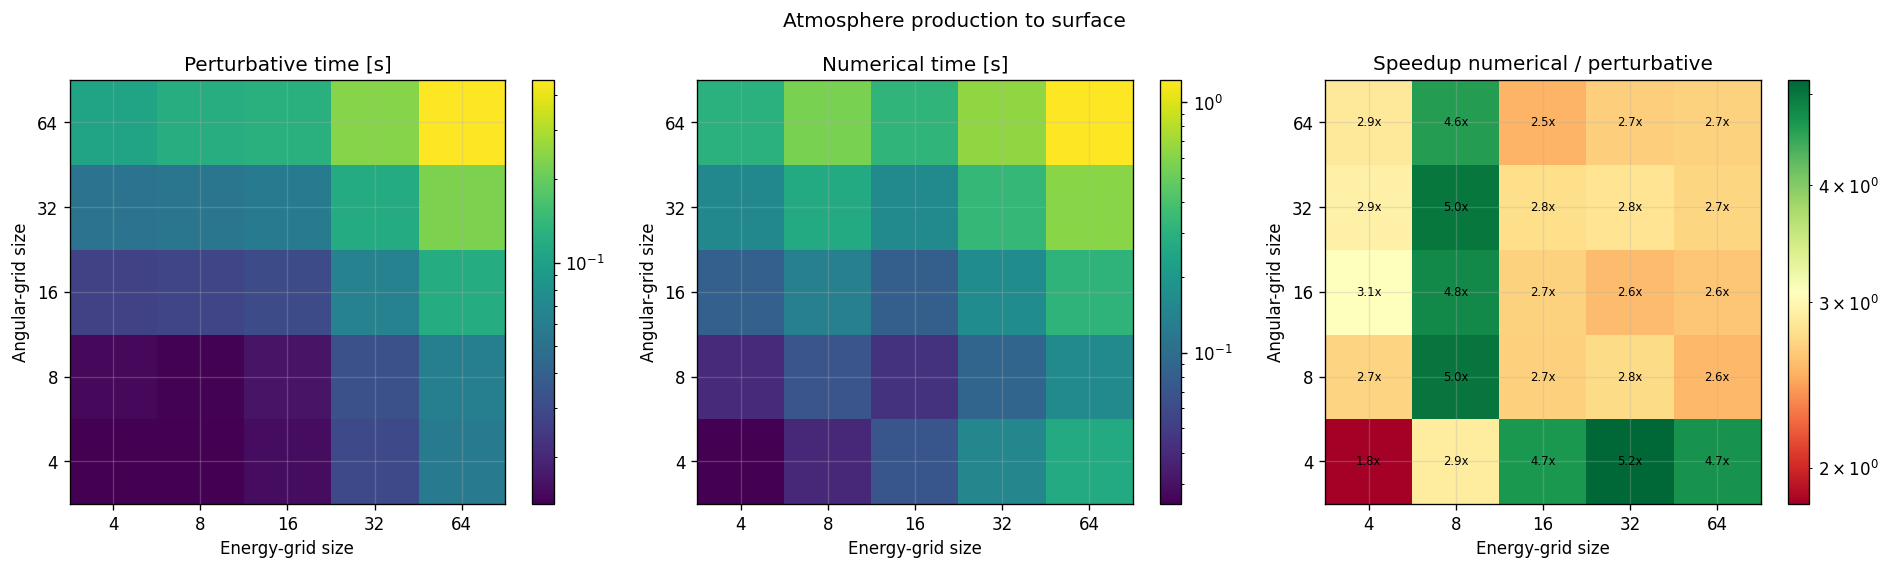

v:\output\benchmark\benchmark1_fig3_atmosphere_surface_scaling.png


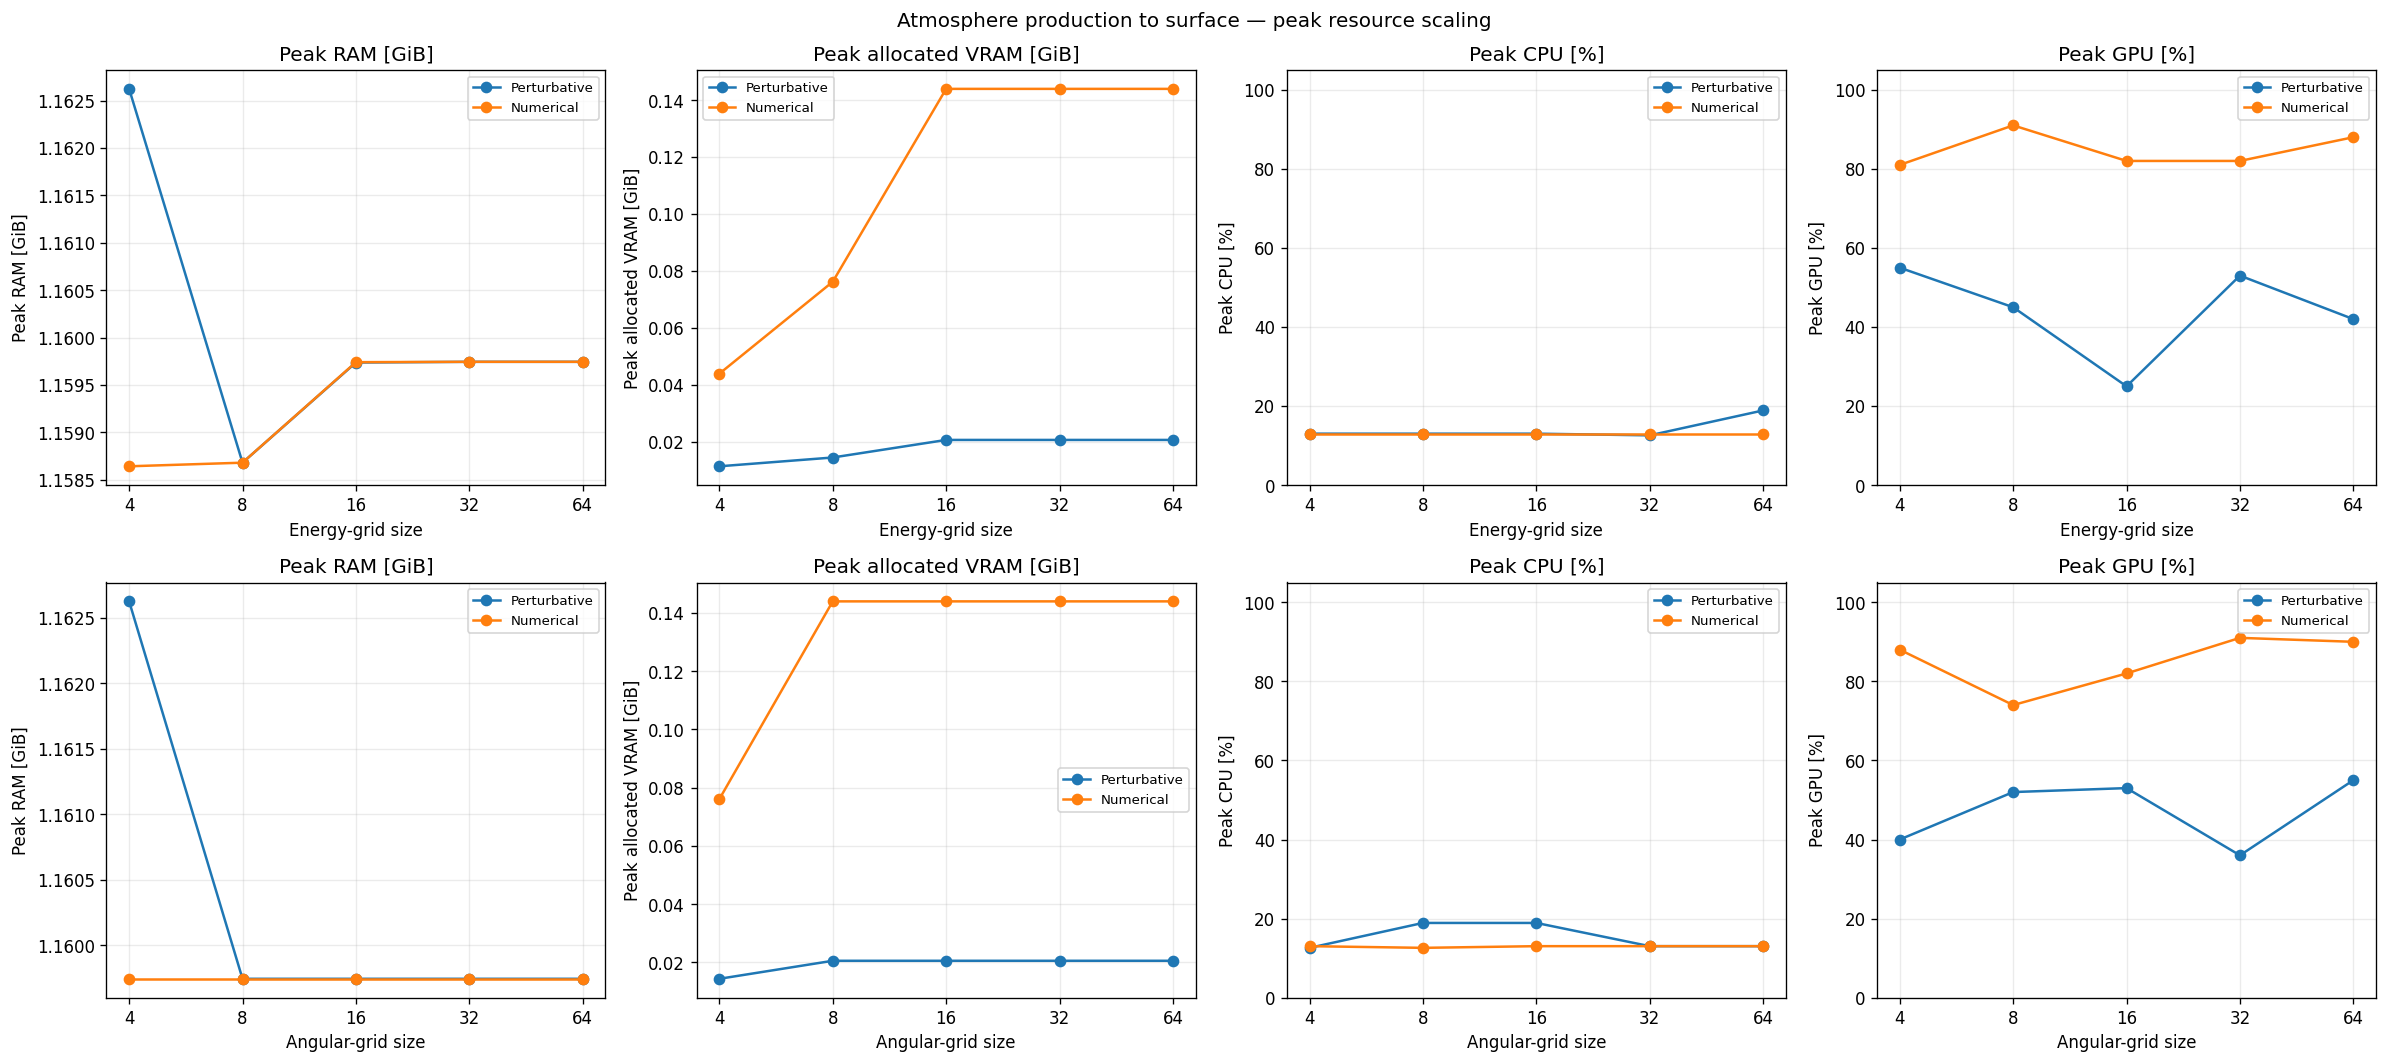

v:\output\benchmark\benchmark1_fig3_atmosphere_surface_resource_scaling.png


In [7]:

atmosphere_surface_df = benchmark_grid('Atmosphere production to surface', atmosphere_surface_workload_factory, 'benchmark1_fig3_atmosphere_surface_scaling.png')


## 6. Atmospheric Neutrinos to the Detector

The end-to-end workload computes the batched atmosphere evolutor, preserves coherent amplitudes at the surface, and propagates each initial flavour through Earth. The analytical Earth stage keeps the joint energy-angle batch; only the numerical Earth stage loops over scalar trajectories.

**Expected results:**<br>
- Total speedup combines the atmosphere advantage with the more moderate Earth advantage.
- Up-going trajectories dominate numerical execution time.
- The accompanying 2×4 resource grid shows peak RAM, allocated VRAM, normalized CPU and GPU utilization versus energy-grid size (top) and angular-grid size (bottom).


Energy Grid Size: 4
.....
Energy Grid Size: 8
.....
Energy Grid Size: 16
.....
Energy Grid Size: 32
.....
Energy Grid Size: 64
.....


,case,n_energy,n_angle,perturbative_s,numerical_s,speedup,perturbative_std_s,numerical_std_s,perturbative_ram_gb,perturbative_cpu_percent,perturbative_gpu_percent,perturbative_vram_allocated_gb,perturbative_vram_reserved_gb,numerical_ram_gb,numerical_cpu_percent,numerical_gpu_percent,numerical_vram_allocated_gb,numerical_vram_reserved_gb
0,Atmosphere production to detector,4,4,0.186099,0.247285,1.328783,0.005332,0.013856,1.167957,12.600,27.0,0.009750,0.021484,1.163940,18.9000,46.0,0.025216,0.041016
1,Atmosphere production to detector,4,8,0.173305,0.382868,2.209218,0.002111,0.002180,1.163940,12.600,17.0,0.011301,0.021484,1.163940,12.6000,43.0,0.043850,0.050781
2,Atmosphere production to detector,4,16,0.271305,0.715283,2.636455,0.000529,0.003548,1.163944,18.900,17.0,0.011303,0.021484,1.163944,12.6000,41.0,0.043888,0.050781
3,Atmosphere production to detector,4,32,0.450586,1.441542,3.199259,0.027827,0.006773,1.163944,12.600,15.0,0.011303,0.021484,1.163944,13.0250,40.0,0.043888,0.050781
4,Atmosphere production to detector,4,64,0.779457,2.849266,3.655448,0.003100,0.015107,1.163944,13.025,16.0,0.011303,0.021484,1.163944,18.9000,40.0,0.043888,0.050781
5,Atmosphere production to detector,8,4,0.150176,0.227969,1.518011,0.002507,0.001596,1.163944,12.600,14.0,0.011295,0.021484,1.163944,18.9000,40.0,0.043762,0.050781
6,Atmosphere production to detector,8,8,0.149959,0.444491,2.964074,0.003247,0.000689,1.163948,12.600,14.0,0.014390,0.021484,1.163948,13.0250,54.0,0.076159,0.099609
7,Atmosphere production to detector,8,16,0.275887,0.894041,3.240607,0.007954,0.011402,1.163952,13.025,17.0,0.014394,0.021484,1.163952,13.0250,61.0,0.076196,0.099609
8,Atmosphere production to detector,8,32,0.454784,1.751452,3.851175,0.001286,0.003921,1.163952,12.600,19.0,0.014394,0.021484,1.163952,12.6000,60.0,0.076196,0.099609
9,Atmosphere production to detector,8,64,0.811905,3.538379,4.358120,0.007281,0.011083,1.163952,13.025,22.0,0.014394,0.021484,1.163952,13.0250,60.0,0.076196,0.099609


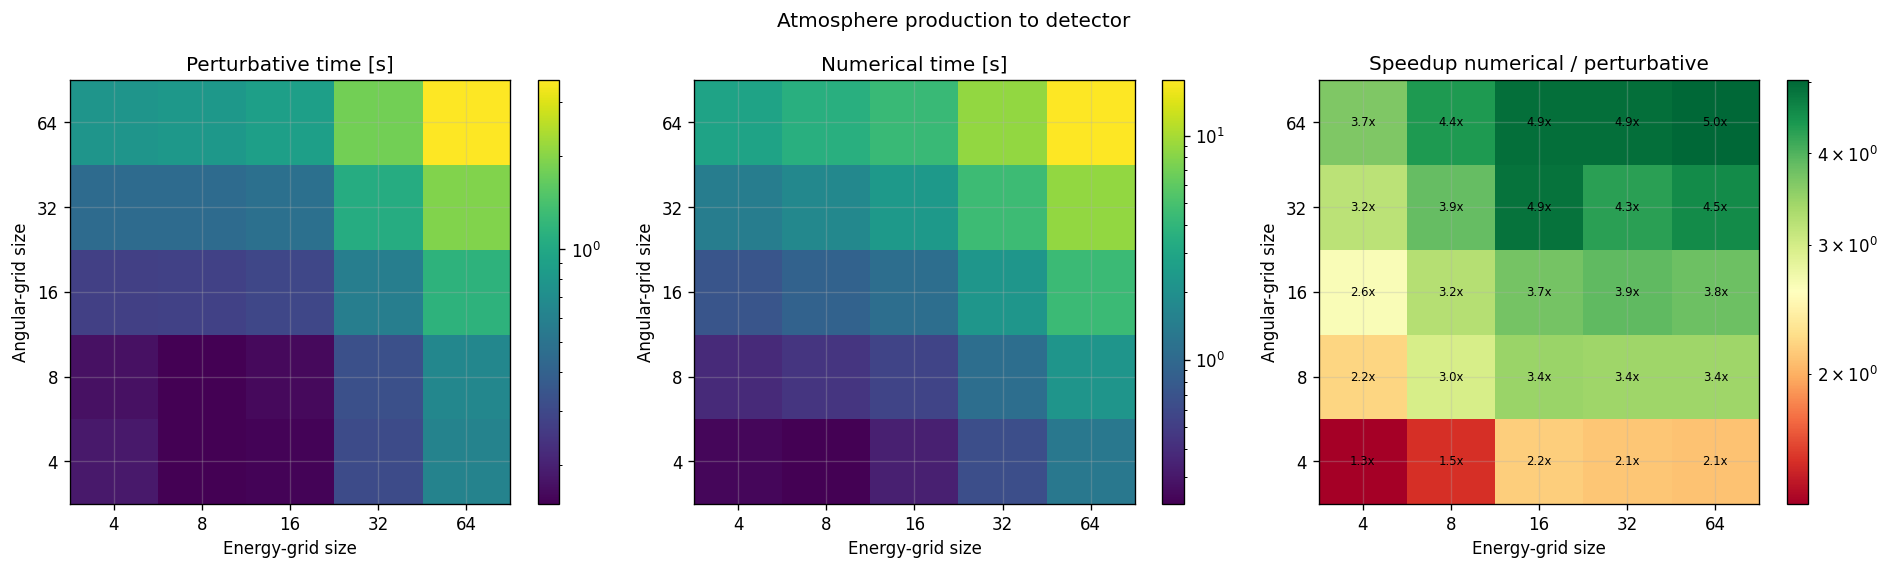

v:\output\benchmark\benchmark1_fig4_atmosphere_detector_scaling.png


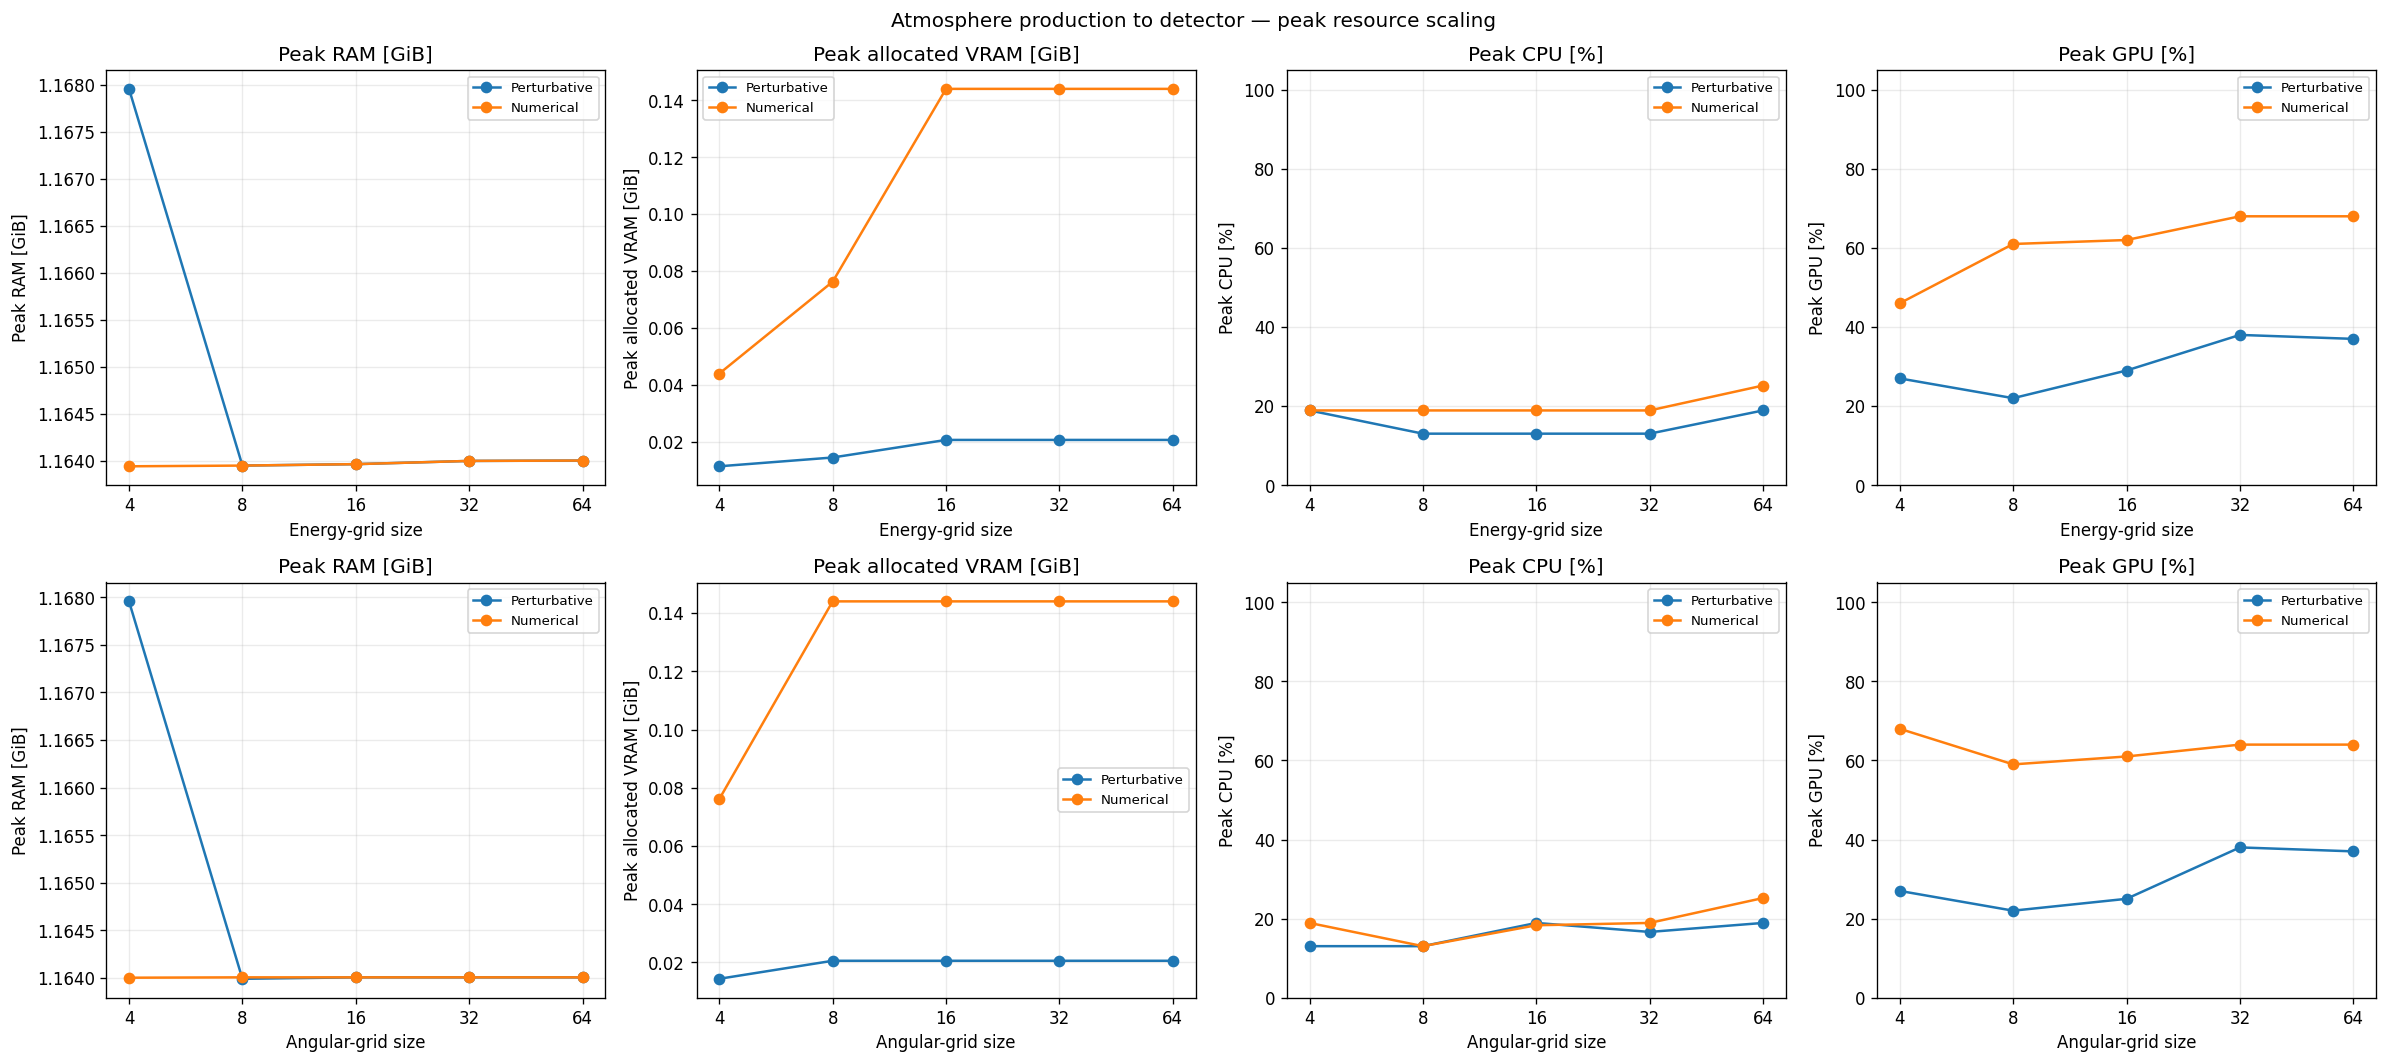

v:\output\benchmark\benchmark1_fig4_atmosphere_detector_resource_scaling.png


In [8]:

atmosphere_detector_df = benchmark_grid('Atmosphere production to detector', atmosphere_detector_workload_factory, 'benchmark1_fig4_atmosphere_detector_scaling.png')


## 7. Resource Consumption

The plots compare the maximum process RAM, allocated/reserved VRAM and process CPU utilization observed in each physical section. Peaks are taken over every grid size and timed repetition, so they represent the most demanding measured configuration rather than an average. CPU utilization is normalized by `CPU_THREADS`, so 100% represents full use of the configured CPU budget.

**Expected results:**<br>
- Process RAM remains below `MAX_RAM_GB`.
- CUDA memory remains below the configured allocator fraction.
- The numerical method should generally require more memory for its discretized trajectories, while CPU utilization remains bounded by the configured thread pools.


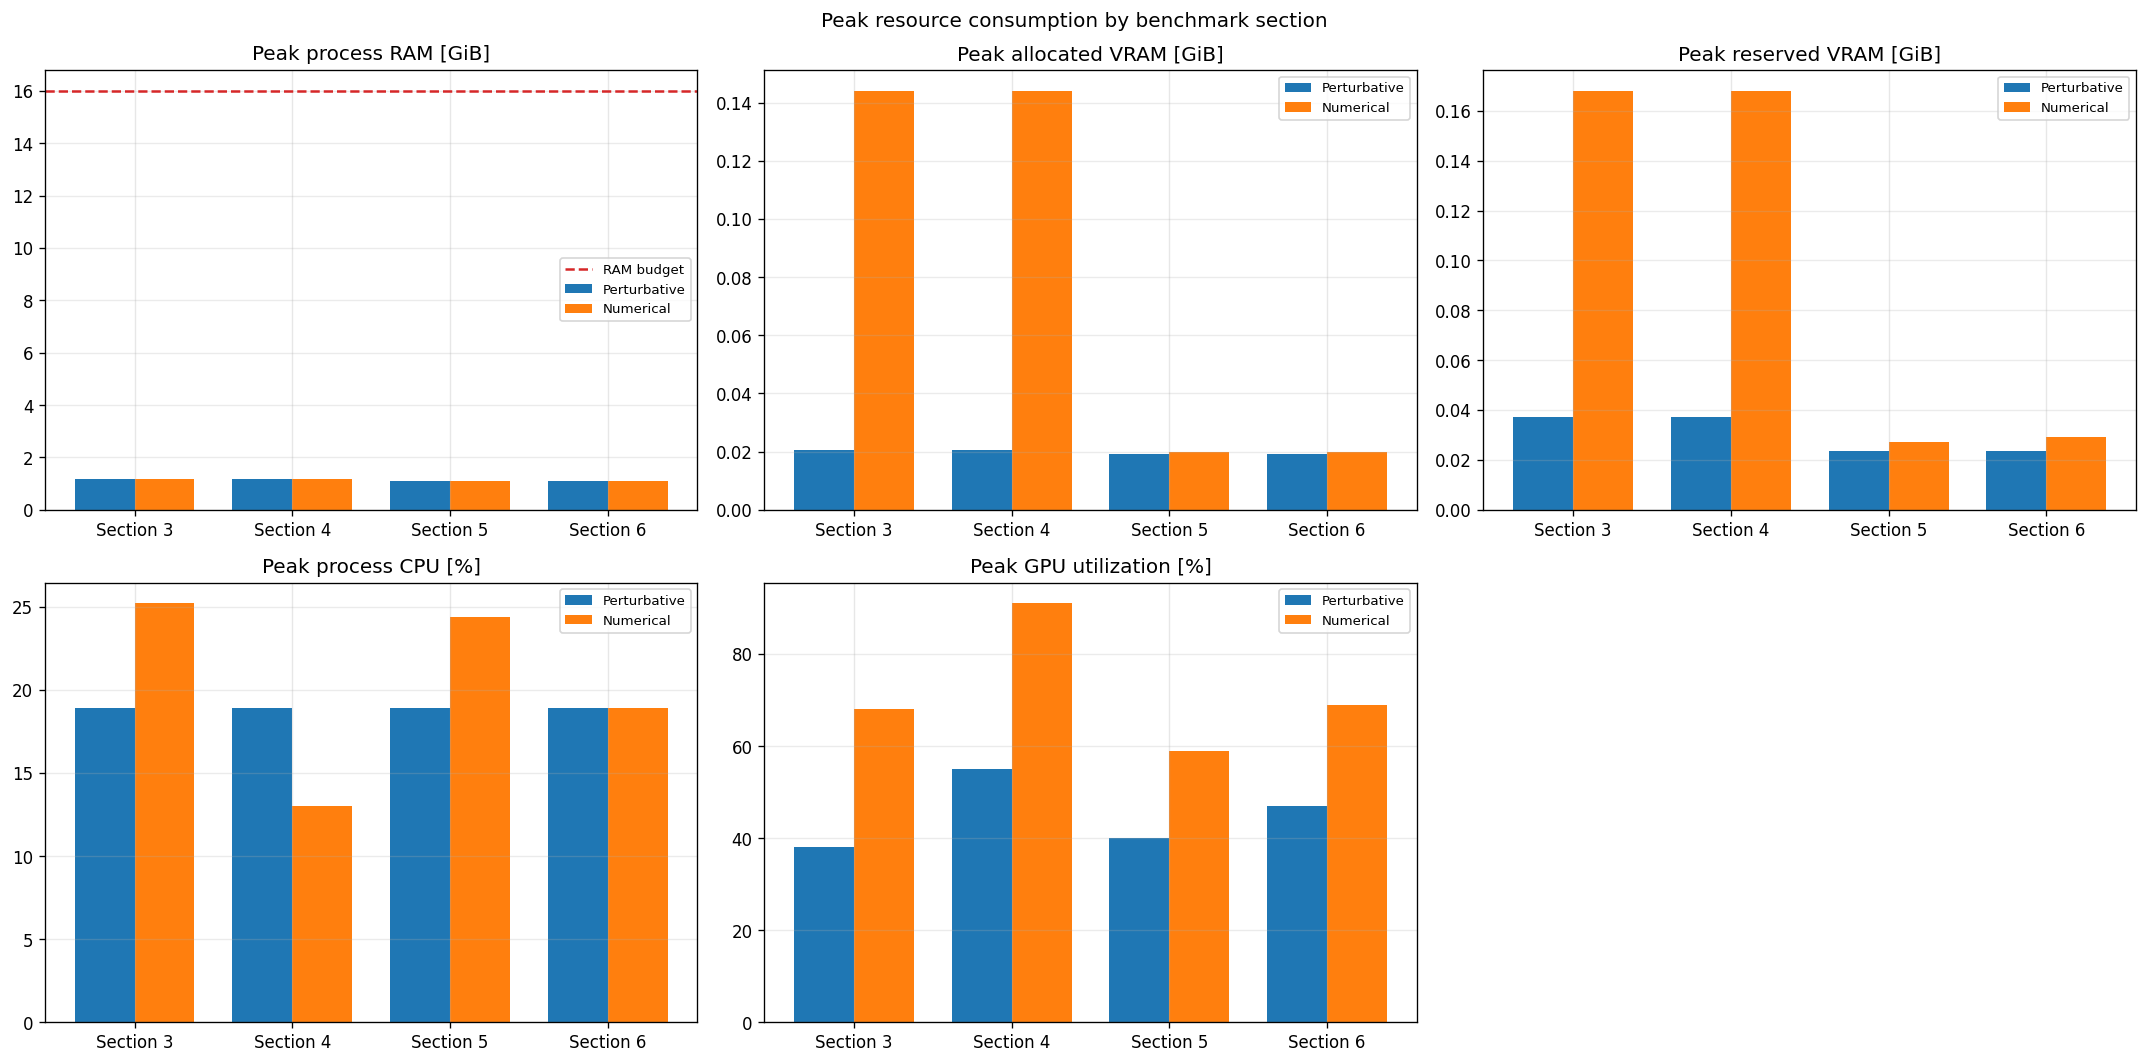

v:\output\benchmark\benchmark1_fig5_resource_consumption.png


ram_gb  vram_allocated_gb  \
case                              method                                      
Atmosphere production to detector perturbative  1.167957           0.020576   
                                  numerical     1.164005           0.144003   
Atmosphere production to surface  perturbative  1.162624           0.020569   
                                  numerical     1.159744           0.143965   
Pure flavour through Earth        perturbative  1.082714           0.019032   
                                  numerical     1.082729           0.019714   
Solar production to detector      perturbative  1.116291           0.019033   
                                  numerical     1.112503           0.019800   

                                                vram_reserved_gb  cpu_percent  \
case                              method                                        
Atmosphere production to detector perturbative          0.037109      18.9000   
                                  numerical             0.167969      25.2000   
Atmosphere production to surface  perturbative          0.037109      18.9000   
                                  numerical             0.167969      13.0250   
Pure flavour through Earth        perturbative          0.023438      18.9000   
                                  numerical             0.027344      24.4125   
Solar production to detector      perturbative          0.023438      18.9000   
                                  numerical             0.029297      18.9000   

                                                gpu_percent  
case                              method                     
Atmosphere production to detector perturbative         38.0  
                                  numerical            68.0  
Atmosphere production to surface  perturbative         55.0  
                                  numerical            91.0  
Pure flavour through Earth        perturbative         40.0  
                                  numerical            59.0  
Solar production to detector      perturbative         47.0  
                                  numerical            69.0

In [9]:
resource_results = pd.concat(benchmark_tables, ignore_index=True)
resource_columns = ['ram_gb', 'vram_allocated_gb', 'vram_reserved_gb', 'cpu_percent', 'gpu_percent']
resource_summary = pd.DataFrame([{'case': case, 'method': method, **{metric: group[f'{method}_{metric}'].max() for metric in resource_columns}} for case, group in resource_results.groupby('case') for method in ('perturbative', 'numerical')])
#display(resource_summary)
resource_summary.to_csv(OUTPUT_DIR / 'benchmark1_resource_summary.csv', index=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
x = np.arange(resource_summary['case'].nunique()); width = 0.38
cases = resource_summary['case'].drop_duplicates().tolist()
for ax, metric, title in zip(axes.flat, resource_columns, ('Peak process RAM [GiB]', 'Peak allocated VRAM [GiB]', 'Peak reserved VRAM [GiB]', 'Peak process CPU [%]', 'Peak GPU utilization [%]')):
    for offset, method in zip((-width/2, width/2), ('perturbative', 'numerical')):
        values = resource_summary[resource_summary.method == method].set_index('case').loc[cases, metric]
        ax.bar(x + offset, values, width, label=method.capitalize())
    ax.set_xticks(x, [f'Section {index + 3}' for index in range(len(cases))]); ax.set_title(title); ax.grid(axis='y', alpha=.25)
    if metric == 'ram_gb': ax.axhline(MAX_RAM_GB, color='tab:red', ls='--', label='RAM budget')
    ax.legend(fontsize=8)
axes.flat[-1].axis('off')
fig.suptitle('Peak resource consumption by benchmark section'); fig.tight_layout(); save_and_show('benchmark1_fig5_resource_consumption.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)
display(resource_summary.set_index(['case', 'method']))

## 8. Summary
The combined table contains one comparison for every $(N_E,N_\theta)$ pair and scenario. The aggregate chart shows diagonal scaling, $N_E=N_\theta$, for execution times and speedup. Raw results are exported to `benchmark1_perturbative_vs_numerical.csv`.

**Expected results:**<br>
all times and speedups are finite and positive. Speedup depends on device, batch size and trajectory discretization; the atmosphere-only workload is expected to benefit most from replacing 600 numerical steps with six perturbative segments.


,case,n_energy,n_angle,perturbative_s,numerical_s,speedup,perturbative_std_s,numerical_std_s,perturbative_ram_gb,perturbative_cpu_percent,perturbative_gpu_percent,perturbative_vram_allocated_gb,perturbative_vram_reserved_gb,numerical_ram_gb,numerical_cpu_percent,numerical_gpu_percent,numerical_vram_allocated_gb,numerical_vram_reserved_gb
0,Pure flavour through Earth,4,4,0.112391,0.176209,1.567823,0.002483,0.013423,1.007568,12.600,11.0,0.009566,0.021484,1.052277,12.600,28.0,0.011060,0.021484
1,Pure flavour through Earth,4,8,0.118988,0.378240,3.178792,0.001547,0.005270,1.052586,12.600,21.0,0.010915,0.021484,1.052631,12.600,41.0,0.011060,0.021484
2,Pure flavour through Earth,4,16,0.235023,0.684120,2.910861,0.003006,0.020249,1.052811,13.025,23.0,0.010915,0.021484,1.052990,12.600,37.0,0.011060,0.021484
3,Pure flavour through Earth,4,32,0.452157,1.386677,3.066806,0.009306,0.030195,1.053017,12.600,24.0,0.010915,0.021484,1.053051,13.025,36.0,0.011060,0.021484
4,Pure flavour through Earth,4,64,0.921286,2.974724,3.228882,0.081798,0.031010,1.053070,13.025,40.0,0.010915,0.021484,1.053524,12.600,35.0,0.011060,0.021484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Atmosphere production to detector,64,4,0.618801,1.299292,2.099691,0.003132,0.003661,1.164001,13.025,18.0,0.014389,0.021484,1.164001,18.900,68.0,0.076090,0.101562
96,Atmosphere production to detector,64,8,0.643783,2.199607,3.416691,0.003704,0.003076,1.163990,13.025,22.0,0.020576,0.037109,1.164005,13.025,59.0,0.144003,0.167969
97,Atmosphere production to detector,64,16,1.160611,4.408137,3.798116,0.013664,0.005795,1.164005,18.900,25.0,0.020576,0.037109,1.164005,16.625,60.0,0.144003,0.167969
98,Atmosphere production to detector,64,32,1.942871,8.830559,4.545109,0.045217,0.043723,1.164005,16.625,34.0,0.020576,0.037109,1.164005,13.025,61.0,0.144003,0.167969


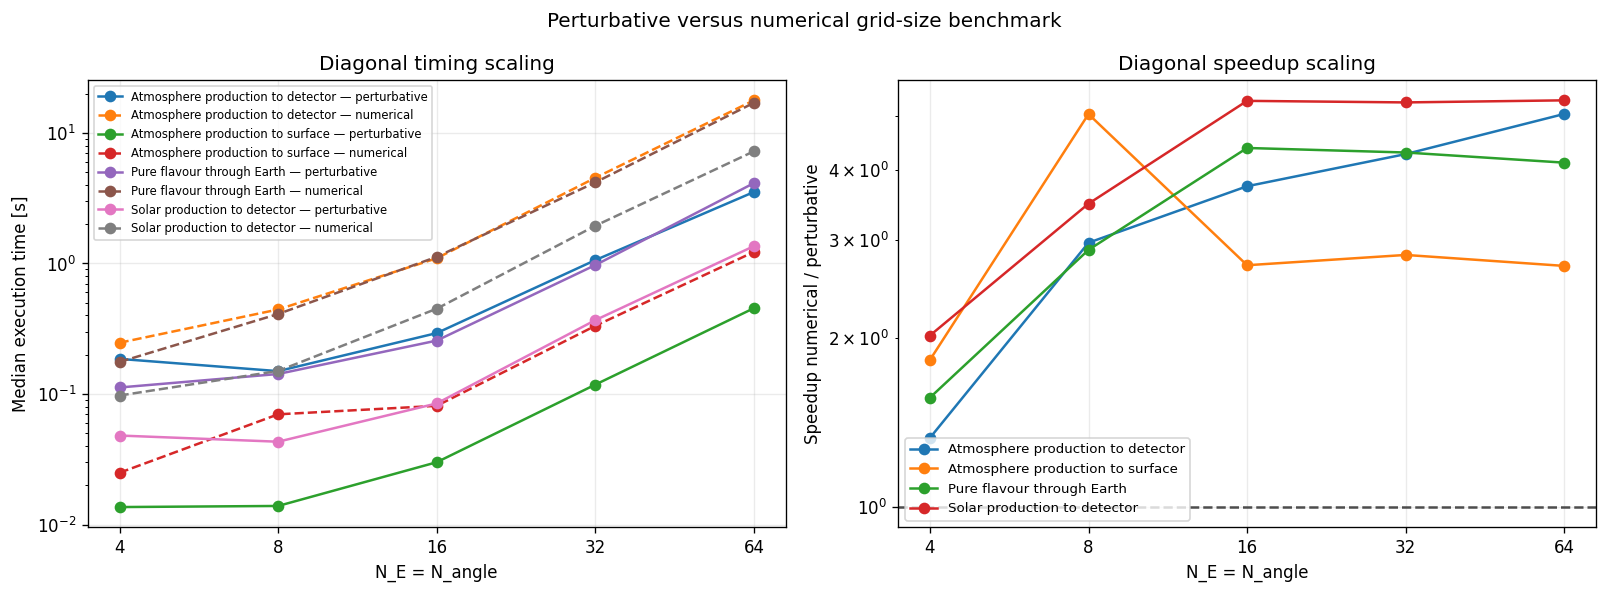

v:\output\benchmark\benchmark1_fig6_summary_scaling.png
All four benchmark scenarios completed successfully.


In [10]:
results = pd.concat(benchmark_tables, ignore_index=True)
display(results)
results.to_csv(OUTPUT_DIR / 'benchmark1_perturbative_vs_numerical.csv', index=False)
numeric_results = results.select_dtypes(include=np.number)
assert np.isfinite(numeric_results.to_numpy()).all() and (results[['perturbative_s', 'numerical_s', 'speedup']] > 0).all().all()
assert (results[['perturbative_ram_gb', 'numerical_ram_gb']] <= MAX_RAM_GB).all().all()

diagonal = results[results.n_energy == results.n_angle]
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
for name, group in diagonal.groupby('case'):
    axes[0].plot(group.n_energy, group.perturbative_s, 'o-', label=f'{name} — perturbative')
    axes[0].plot(group.n_energy, group.numerical_s, 'o--', label=f'{name} — numerical')
    axes[1].plot(group.n_energy, group.speedup, 'o-', label=name)
for ax in axes: ax.set_xscale('log', base=2); ax.set_xticks(ENERGY_GRID_SIZES, ENERGY_GRID_SIZES); ax.grid(alpha=.25)
axes[0].set_yscale('log'); axes[0].set(xlabel='N_E = N_angle', ylabel='Median execution time [s]', title='Diagonal timing scaling'); axes[0].legend(fontsize=7)
axes[1].axhline(1.0, color='0.3', ls='--'); axes[1].set_yscale('log'); axes[1].set(xlabel='N_E = N_angle', ylabel='Speedup numerical / perturbative', title='Diagonal speedup scaling'); axes[1].legend(fontsize=8)
fig.suptitle('Perturbative versus numerical grid-size benchmark'); fig.tight_layout(); save_and_show('benchmark1_fig6_summary_scaling.png', fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)
print('All four benchmark scenarios completed successfully.')